# AndroZoo Sequence Model Inference

This notebook performs temporal inference on the AndroZoo 2024--2026 sequence hold-out using all sequence models trained on KronoDroid. It does not refit vocabulary, thresholds, preprocessing, or model parameters on AndroZoo.

In [1]:
# Imports and path configuration
from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, confusion_matrix, classification_report

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')

SEED = 42
BATCH_SIZE = 128

CANDIDATE_DATA_DIRS = [Path('../androzoo_dataset'), Path('dynamic_ieee_paper/androzoo_dataset'), Path('androzoo_dataset')]
DATA_DIR = next((p for p in CANDIDATE_DATA_DIRS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError('Could not locate androzoo_dataset. Run from project root or dynamic_ieee_paper/deneyler.')

CANDIDATE_RESULT_DIRS = [Path('results'), Path('dynamic_ieee_paper/deneyler/results')]
BASE_RESULT_DIR = next((p for p in CANDIDATE_RESULT_DIRS if p.exists()), None)
if BASE_RESULT_DIR is None:
    raise FileNotFoundError('Could not locate deneyler/results. Run the KronoDroid sequence notebook first.')

CHECKPOINT_PATHS = sorted(BASE_RESULT_DIR.glob('kronodroid_sequence_*.pt'))
CHECKPOINT_PATHS = [p for p in CHECKPOINT_PATHS if p.stem.replace('kronodroid_sequence_', '') in {'bilstm', 'transformer'}]
if not CHECKPOINT_PATHS:
    raise FileNotFoundError('No sequence checkpoints found: expected kronodroid_sequence_bilstm.pt and/or kronodroid_sequence_transformer.pt')

RESULT_DIR = BASE_RESULT_DIR / 'androzoo_sequence_inference'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Data directory :', DATA_DIR.resolve())
print('Base result dir:', BASE_RESULT_DIR.resolve())
print('Result dir     :', RESULT_DIR.resolve())
print('Checkpoints    :', [p.name for p in CHECKPOINT_PATHS])
print('Device         :', DEVICE)

Data directory : /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/androzoo_dataset
Base result dir: /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results
Result dir     : /home/tan/GitHub/paper-kangal-dynamic/dynamic_ieee_paper/deneyler/results/androzoo_sequence_inference
Checkpoints    : ['kronodroid_sequence_bilstm.pt', 'kronodroid_sequence_transformer.pt']
Device         : cuda


In [2]:
# Load AndroZoo sequence hold-out
def read_jsonl(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            seq = obj.get('seq_log', [])
            rows.append({
                'package_name': obj.get('package_name'),
                'label': obj.get('label'),
                'seq_len': obj.get('seq_len', len(seq)),
                'session_duration_ms': obj.get('session_duration_ms', 0),
                'tags': [ev.get('tag', 'UNK') for ev in seq],
            })
    return pd.DataFrame(rows)

df_ben = read_jsonl(DATA_DIR / 'androzoo_benign_seqlogs.jsonl').head(3000).copy()
df_mal = read_jsonl(DATA_DIR / 'androzoo_malware_seqlogs.jsonl').head(3000).copy()
df = pd.concat([df_ben, df_mal], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
df['label_bin'] = (df['label'] == 'malware').astype(int)

print(f'Benign : {len(df_ben):,}')
print(f'Malware: {len(df_mal):,}')
print(f'Total  : {len(df):,}')
print(df.groupby('label')['seq_len'].describe()[['min','50%','mean','max']])

Benign : 3,000
Malware: 3,000
Total  : 6,000
          min   50%        mean    max
label                                 
benign   10.0  96.0   97.913000  364.0
malware  10.0  95.5  104.424667  308.0


In [3]:
# Model definitions matching the KronoDroid training notebook
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=96, hidden_dim=128, num_layers=2, dropout=0.2, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(nn.LayerNorm(hidden_dim * 2), nn.Dropout(dropout), nn.Linear(hidden_dim * 2, 1))

    def forward(self, input_ids, attention_mask, length):
        emb = self.embedding(input_ids)
        lengths = length.detach().cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        h = torch.cat([h_n[-2], h_n[-1]], dim=1)
        return self.head(h).squeeze(1)

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=96, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.2, pad_id=0, max_seq_len=256):
        super().__init__()
        self.pad_id = pad_id
        self.max_seq_len = max_seq_len
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_id)
        self.pos_emb = nn.Embedding(max_seq_len, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(nn.LayerNorm(embed_dim), nn.Dropout(dropout), nn.Linear(embed_dim, 1))

    def forward(self, input_ids, attention_mask, length):
        bsz, seqlen = input_ids.shape
        pos = torch.arange(seqlen, device=input_ids.device).unsqueeze(0).expand(bsz, seqlen)
        x = self.token_emb(input_ids) + self.pos_emb(pos)
        key_padding_mask = attention_mask == 0
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)
        mask = attention_mask.unsqueeze(-1)
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        return self.head(pooled).squeeze(1)

def infer_model_name(path):
    name = path.stem.replace('kronodroid_sequence_', '')
    if name == 'bilstm':
        return 'BiLSTM'
    if name == 'transformer':
        return 'Transformer'
    return name

def build_model(model_name, vocab_size, max_seq_len, pad_id):
    if model_name == 'BiLSTM':
        return BiLSTMClassifier(vocab_size=vocab_size, pad_id=pad_id)
    if model_name == 'Transformer':
        return TransformerClassifier(vocab_size=vocab_size, pad_id=pad_id, max_seq_len=max_seq_len)
    raise ValueError(f'Unknown model_name: {model_name}')

In [4]:
# Dataset factory using each checkpoint's frozen KronoDroid vocabulary
class SequenceDataset(Dataset):
    def __init__(self, frame, stoi, pad_id, unk_id, max_len):
        self.frame = frame.reset_index(drop=True)
        self.stoi = stoi
        self.pad_id = pad_id
        self.unk_id = unk_id
        self.max_len = max_len

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        ids = [self.stoi.get(t, self.unk_id) for t in row['tags'][:self.max_len]]
        length = min(len(ids), self.max_len)
        if length < self.max_len:
            ids = ids + [self.pad_id] * (self.max_len - length)
        attn = [1] * length + [0] * (self.max_len - length)
        return {
            'input_ids': torch.tensor(ids, dtype=torch.long),
            'attention_mask': torch.tensor(attn, dtype=torch.float32),
            'length': torch.tensor(max(length, 1), dtype=torch.long),
            'label': torch.tensor(row['label_bin'], dtype=torch.float32),
            'package_name': row['package_name'],
            'seq_len': torch.tensor(row['seq_len'], dtype=torch.long),
        }

def make_loader(stoi, pad_id, unk_id, max_seq_len):
    ds = SequenceDataset(df, stoi=stoi, pad_id=pad_id, unk_id=unk_id, max_len=max_seq_len)
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [5]:
# Run temporal inference for all trained sequence checkpoints
def evaluate(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
    return {
        'threshold': threshold,
        'accuracy': accuracy_score(labels, preds),
        'macro_f1': f1_score(labels, preds, average='macro'),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'roc_auc': roc_auc_score(labels, probs),
        'pr_auc': average_precision_score(labels, probs),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
        'fpr': fp / (fp + tn),
        'fnr': fn / (fn + tp),
    }

all_metrics = []
all_reports = {}
for ckpt_path in CHECKPOINT_PATHS:
    model_name = infer_model_name(ckpt_path)
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    stoi = ckpt['stoi']
    itos = ckpt['itos']
    pad_id = int(stoi.get('<PAD>', 0))
    unk_id = int(stoi.get('<UNK>', 1))
    max_seq_len = int(ckpt.get('max_seq_len', 256))
    vocab_size = len(itos)
    loader = make_loader(stoi, pad_id, unk_id, max_seq_len)

    model = build_model(model_name, vocab_size, max_seq_len, pad_id).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    probs, labels, package_names, seq_lens = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            length = batch['length'].to(DEVICE)
            logits = model(input_ids, attention_mask, length)
            probs.extend(torch.sigmoid(logits).detach().cpu().numpy().tolist())
            labels.extend(batch['label'].numpy().tolist())
            package_names.extend(batch['package_name'])
            seq_lens.extend(batch['seq_len'].numpy().tolist())

    probs = np.array(probs)
    labels = np.array(labels).astype(int)
    threshold = 0.5
    preds = (probs >= threshold).astype(int)
    metrics = {'model': model_name, **evaluate(labels, probs, threshold)}
    all_metrics.append(metrics)
    all_reports[model_name] = classification_report(labels, preds, target_names=['benign', 'malware'], output_dict=True)

    pred_df = pd.DataFrame({
        'package_name': package_names,
        'label': np.where(labels == 1, 'malware', 'benign'),
        'label_bin': labels,
        'malware_probability': probs,
        'prediction_bin': preds,
        'prediction': np.where(preds == 1, 'malware', 'benign'),
        'seq_len': seq_lens,
    })
    pred_path = RESULT_DIR / f'androzoo_sequence_predictions_{model_name.lower()}.csv'
    pred_df.to_csv(pred_path, index=False)
    print(f'{model_name}: predictions written to {pred_path}')

metrics_df = pd.DataFrame(all_metrics).sort_values(['roc_auc', 'macro_f1'], ascending=False)
metrics_df.to_csv(RESULT_DIR / 'androzoo_sequence_metrics_all_models.csv', index=False)
# Backward-compatible copy: best model row only.
metrics_df.head(1).to_csv(RESULT_DIR / 'androzoo_sequence_metrics.csv', index=False)
with open(RESULT_DIR / 'androzoo_sequence_classification_reports_all_models.json', 'w') as f:
    json.dump(all_reports, f, indent=2)
metrics_df.round(4)

BiLSTM: predictions written to results/androzoo_sequence_inference/androzoo_sequence_predictions_bilstm.csv
Transformer: predictions written to results/androzoo_sequence_inference/androzoo_sequence_predictions_transformer.csv


,model,threshold,accuracy,macro_f1,precision,recall,roc_auc,pr_auc,tn,fp,fn,tp,fpr,fnr
1,Transformer,0.5,0.7760,0.7746,0.8270,0.6980,0.8525,0.8591,2562,438,906,2094,0.146,0.3020
0,BiLSTM,0.5,0.7988,0.7988,0.7948,0.8057,0.8371,0.7968,2376,624,583,2417,0.208,0.1943


In [6]:
# Compare KronoDroid source validation and AndroZoo temporal inference
source_path = BASE_RESULT_DIR / 'kronodroid_sequence_results.csv'
if source_path.exists():
    source = pd.read_csv(source_path)
    source = source[['model', 'accuracy', 'macro_f1', 'roc_auc', 'pr_auc', 'tn', 'fp', 'fn', 'tp']].copy()
    source['fpr'] = source['fp'] / (source['fp'] + source['tn'])
    source['fnr'] = source['fn'] / (source['fn'] + source['tp'])
    merged = source.merge(metrics_df, on='model', suffixes=('_krono_val', '_androzoo'))
    for metric in ['accuracy', 'macro_f1', 'roc_auc', 'pr_auc', 'fpr', 'fnr']:
        merged[f'delta_{metric}'] = merged[f'{metric}_androzoo'] - merged[f'{metric}_krono_val']
    compare_cols = [
        'model',
        'macro_f1_krono_val', 'macro_f1_androzoo', 'delta_macro_f1',
        'roc_auc_krono_val', 'roc_auc_androzoo', 'delta_roc_auc',
        'fpr_krono_val', 'fpr_androzoo', 'delta_fpr',
        'fnr_krono_val', 'fnr_androzoo', 'delta_fnr',
    ]
    comparison = merged[compare_cols].sort_values('macro_f1_androzoo', ascending=False)
    comparison.to_csv(RESULT_DIR / 'sequence_source_vs_androzoo_comparison.csv', index=False)
    display(comparison.round(4))
else:
    print('Source validation results not found:', source_path)

,model,macro_f1_krono_val,macro_f1_androzoo,delta_macro_f1,roc_auc_krono_val,roc_auc_androzoo,delta_roc_auc,fpr_krono_val,fpr_androzoo,delta_fpr,fnr_krono_val,fnr_androzoo,delta_fnr
1,BiLSTM,0.9587,0.7988,-0.1598,0.9885,0.8371,-0.1514,0.0373,0.208,0.1707,0.0453,0.1943,0.1490
0,Transformer,0.9627,0.7746,-0.1880,0.9905,0.8525,-0.1380,0.0293,0.146,0.1167,0.0453,0.3020,0.2567


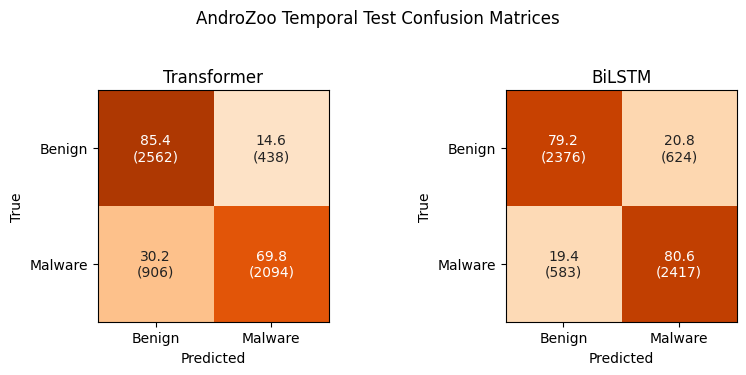

In [7]:
# Confusion matrix figure for temporal test, all sequence models
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(metrics_df), figsize=(4.2 * len(metrics_df), 3.6))
if len(metrics_df) == 1:
    axes = [axes]
for ax, (_, row) in zip(axes, metrics_df.iterrows()):
    cm = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    ax.imshow(cm_norm, cmap='Oranges', vmin=0.0, vmax=1.0)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_norm[i, j]*100:.1f}\n({int(cm[i, j])})', ha='center', va='center', color='white' if cm_norm[i, j] > 0.55 else '#222222', fontsize=10)
    ax.set_title(str(row['model']))
    ax.set_xticks([0, 1], ['Benign', 'Malware'])
    ax.set_yticks([0, 1], ['Benign', 'Malware'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
fig.suptitle('AndroZoo Temporal Test Confusion Matrices', y=1.03, fontsize=12)
fig.tight_layout()
fig.savefig(RESULT_DIR / 'androzoo_sequence_confusion_matrices_all_models.pdf', bbox_inches='tight')
fig.savefig(RESULT_DIR / 'androzoo_sequence_confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
# Backward-compatible names for the best row figure are no longer updated; use *_all_models files.
plt.show()